# Held-Out Test: `TodPennnyOIThresholdStrategy`

This notebook runs the final held-out workflow only:

1. Fit `TodPennnyOIThresholdStrategy` on all of `data-train`
2. Evaluate the frozen fitted strategy on all of `data-test`

It does not use the internal `train_frac` split from the development pipeline.

## Colab Setup

This cell prepares a clean Colab environment. It clones the repo into `/content/optimal-execution`, mounts Google Drive, copies the held-out `train` and `test` CSV folders into `data-train` and `data-test`, and installs the Python dependencies needed to run the notebook.

If you are running locally and already have the repo plus data directories set up, skip this cell.

In [45]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print('Local environment detected. Skip this cell if your repo and data are already set up.')
else:
    drive.mount('/content/drive')
    os.chdir('/content')

    repo_dir = Path('/content/optimal-execution')
    if repo_dir.exists():
        shutil.rmtree(repo_dir)

    subprocess.run(
        ['git', 'clone', 'https://github.com/MatteoPerona/optimal-execution.git'],
        check=True,
    )
    os.chdir(repo_dir)
    subprocess.run(['git', 'checkout', 'testing'], check=True)

    shutil.rmtree('data-train', ignore_errors=True)
    shutil.rmtree('data-test', ignore_errors=True)
    shutil.copytree('/content/drive/MyDrive/cs5259data/train', 'data-train')
    shutil.copytree('/content/drive/MyDrive/cs5259data/test', 'data-test')

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'scipy', 'matplotlib', 'jupyter', 'ipython'],
        check=True,
    )

    print(f'Working directory: {Path.cwd()}')
    print('Train files:', sorted(os.listdir('data-train'))[:5])
    print('Test files:', sorted(os.listdir('data-test'))[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/optimal-execution
Train files: ['AAPL_5levels_train.csv', 'AMZN_5levels_train.csv', 'GOOG_5levels_train.csv', 'INTC_5levels_train.csv', 'MSFT_5levels_train.csv']
Test files: ['AAPL_5levels_test.csv', 'AMZN_5levels_test.csv', 'GOOG_5levels_test.csv', 'INTC_5levels_test.csv', 'MSFT_5levels_test.csv']


In [46]:
import os
from pathlib import Path

repo_root = Path.cwd()
if repo_root.name == 'heldout_test':
    repo_root = repo_root.parent
elif repo_root.name != 'optimal-execution' and (repo_root / 'optimal-execution').exists():
    repo_root = repo_root / 'optimal-execution'

os.chdir(repo_root)
print(f'Working directory: {Path.cwd()}')

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.strategy import TodPennnyOIThresholdStrategy
from utils.evaluation import print_results, plot_results, evaluate_both_sides, evaluate_strategy
from heldout_test import run_external_test_experiment

Working directory: /content/optimal-execution


In [47]:
heldout_config = DEFAULT_CONFIG.copy()
heldout_config['stocks'] = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
heldout_config['train_data_dir'] = 'data-train'
heldout_config['test_data_dir'] = 'data-test'

heldout_config

{'stocks': ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT'],
 'data_dir': 'data',
 'penny_spread_cutoff': 0.02,
 'train_frac': 0.7,
 'imb_grid': (0.52, 0.95, 30),
 'spread_grid_penny': (0.005, 0.03, 20),
 'spread_grid_wide': (0.05, 0.5, 20),
 'smooth_size': 3,
 'horizons': (10, 20, 30, 60),
 'n_bins': 20,
 'train_data_dir': 'data-train',
 'test_data_dir': 'data-test'}

In [48]:
todpennny_heldout_results = run_external_test_experiment(
    TodPennnyOIThresholdStrategy,
    heldout_config,
    signal_fn='oi',
)

todpennny_heldout_results['fitted']

Running held-out test experiment: todpennny (signal=oi)


  train AAPL: wide
  train AMZN: wide
  train GOOG: wide
  train INTC: penny
  train MSFT: penny
  Train rows: 1,404,889
  Fitting parameters on full train set...
    wide: theta_imb=0.5200, theta_spread=0.1211
  Test rows:  705,971
  Backtesting on full held-out test set...


{('penny', 570): {'theta_imb': 0.982227331648816,
  'theta_spread': 0.016243429580749695},
 ('penny', 571): {'theta_imb': 0.9795848492989915,
  'theta_spread': 0.015860965030117198},
 ('penny', 572): {'theta_imb': 0.9728056006511115,
  'theta_spread': 0.014879757988976686},
 ('penny', 573): {'theta_imb': 0.9675418448974122,
  'theta_spread': 0.014117898603572833},
 ('penny', 574): {'theta_imb': 0.9654190786807414,
  'theta_spread': 0.013810656124844159},
 ('penny', 575): {'theta_imb': 0.9664611941570773,
  'theta_spread': 0.013961488627998037},
 ('penny', 576): {'theta_imb': 0.9682190431799703,
  'theta_spread': 0.014215914144469396},
 ('penny', 577): {'theta_imb': 0.9654384135241787,
  'theta_spread': 0.013813454589025874},
 ('penny', 578): {'theta_imb': 0.9677229237204635,
  'theta_spread': 0.01414410738059342},
 ('penny', 579): {'theta_imb': 0.9649463393606876,
  'theta_spread': 0.01374223332852059},
 ('penny', 580): {'theta_imb': 0.9654661126400729,
  'theta_spread': 0.013817463671

## First-Tick Benchmark Metric Table

This section computes the reported metric using the first tick of each minute as the benchmark instead of the minute-average TWAP. The fitted `TodPennnyOIThresholdStrategy` is unchanged; only the reporting benchmark is different.

`100 - 100 * (TOTAL_YOURALGO_BUY - TOTAL_YOURALGO_SELL) / (TOTAL_FIRSTTICK_BUY - TOTAL_FIRSTTICK_SELL)`


In [49]:
def benchmark_metric_from_side_results(buy_df, sell_df):
    total_first_buy = (buy_df['twap'] - buy_df['first_tick']).sum()
    total_first_sell = (sell_df['twap'] + sell_df['first_tick']).sum()
    total_algo_buy = (buy_df['twap'] - buy_df['strategy']).sum()
    total_algo_sell = (sell_df['twap'] + sell_df['strategy']).sum()

    denominator = total_first_buy - total_first_sell
    numerator = total_algo_buy - total_algo_sell
    metric = 100 - 100 * numerator / denominator

    return pd.Series({
        'n_buy_minutes': len(buy_df),
        'n_sell_minutes': len(sell_df),
        'total_first_buy': total_first_buy,
        'total_first_sell': total_first_sell,
        'total_algo_buy': total_algo_buy,
        'total_algo_sell': total_algo_sell,
        'total_improvement_vs_first_tick': (buy_df['strategy'] - buy_df['first_tick']).sum() + (sell_df['strategy'] - sell_df['first_tick']).sum(),
        'benchmark_metric': metric,
    })

train_buy = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['train_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='buy',
)
train_sell = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['train_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='sell',
)
test_buy = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['test_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='buy',
)
test_sell = evaluate_strategy(
    TodPennnyOIThresholdStrategy,
    todpennny_heldout_results['test_data'],
    todpennny_heldout_results['fitted'],
    signal_fn='oi',
    side='sell',
)

overall_metric_table = pd.DataFrame({
    'train': benchmark_metric_from_side_results(train_buy, train_sell),
    'test': benchmark_metric_from_side_results(test_buy, test_sell),
}).T
overall_metric_table


,n_buy_minutes,n_sell_minutes,total_first_buy,total_first_sell,total_algo_buy,total_algo_sell,total_improvement_vs_first_tick,benchmark_metric
train,1350.0,1350.0,388479.18,388312.45,388433.33,388339.50,72.90,43.723385
test,600.0,600.0,171107.14,171050.28,171092.27,171063.04,27.63,48.593036


In [50]:
def metric_by_stock(buy_df, sell_df, split_name):
    buy_parts = {ticker: grp for ticker, grp in buy_df.groupby('ticker')}
    sell_parts = {ticker: grp for ticker, grp in sell_df.groupby('ticker')}
    rows = []
    for ticker in sorted(set(buy_parts) | set(sell_parts)):
        buy_part = buy_parts.get(ticker, buy_df.iloc[0:0].copy())
        sell_part = sell_parts.get(ticker, sell_df.iloc[0:0].copy())
        row = benchmark_metric_from_side_results(buy_part, sell_part).to_dict()
        row['split'] = split_name
        row['ticker'] = ticker
        row['archetype'] = (buy_part['archetype'].iloc[0] if len(buy_part) else sell_part['archetype'].iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)

train_stock_metrics = metric_by_stock(train_buy, train_sell, 'train')
test_stock_metrics = metric_by_stock(test_buy, test_sell, 'test')
course_metric_table = pd.concat([train_stock_metrics, test_stock_metrics], ignore_index=True)
course_metric_table = course_metric_table.sort_values(['split', 'archetype', 'ticker']).reset_index(drop=True)
course_metric_table[['split', 'ticker', 'archetype', 'benchmark_metric', 'total_improvement_vs_first_tick', 'n_buy_minutes', 'n_sell_minutes']]


,split,ticker,archetype,benchmark_metric,total_improvement_vs_first_tick,n_buy_minutes,n_sell_minutes
0,test,INTC,penny,96.666667,1.16,120.0,120.0
1,test,MSFT,penny,111.666667,1.34,120.0,120.0
2,test,AAPL,wide,39.772727,5.60,120.0,120.0
3,test,AMZN,wide,35.281065,4.77,120.0,120.0
4,test,GOOG,wide,54.951601,14.76,120.0,120.0
5,train,INTC,penny,106.884058,2.95,270.0,270.0
6,train,MSFT,penny,119.272727,3.28,270.0,270.0
7,train,AAPL,wide,53.251121,23.75,270.0,270.0
8,train,AMZN,wide,40.160000,15.06,270.0,270.0
9,train,GOOG,wide,35.212336,27.86,270.0,270.0


## Submission-Ready Row

This section reshapes the computed train/test first-tick benchmark metric into the stock order used in the course reporting sheet: Intel, Microsoft, Amazon, Google, Apple. Fill in your time slot and team names, then copy the row values into the shared table.


In [51]:
stock_name_map = {
    'INTC': 'Intel',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'GOOG': 'Google',
    'AAPL': 'Apple',
}
stock_order = ['Intel', 'Microsoft', 'Amazon', 'Google', 'Apple']
split_order = ['train', 'test']

submission_values = course_metric_table[['split', 'ticker', 'benchmark_metric']].copy()
submission_values['stock_name'] = submission_values['ticker'].map(stock_name_map)
submission_values['metric_pct'] = submission_values['benchmark_metric'].map(lambda x: f'{x:.2f}%')
submission_series = submission_values.set_index(['stock_name', 'split'])['metric_pct']
submission_series = submission_series.reindex(pd.MultiIndex.from_product([stock_order, split_order]))
submission_row = submission_series.to_frame().T
submission_row.columns = [f'{stock} {split.title()}' for stock, split in submission_row.columns]
submission_row.index = ['TodPennnyOIThresholdStrategy']
submission_row


,Intel Train,Intel Test,Microsoft Train,Microsoft Test,Amazon Train,Amazon Test,Google Train,Google Test,Apple Train,Apple Test
TodPennnyOIThresholdStrategy,106.88%,96.67%,119.27%,111.67%,40.16%,35.28%,35.21%,54.95%,53.25%,39.77%


Mean Improvement over First Tick ($)
  Penny  (n= 480, win_rate=37.7%)  todpennny: $+0.005208  First Tick: $0.000000  Last Tick: $+0.000000
  Wide   (n= 720, win_rate=48.2%)  todpennny: $+0.034903  First Tick: $0.000000  Last Tick: $-0.000153
  All    (n=1200, win_rate=44.0%)  todpennny: $+0.023025  First Tick: $0.000000  Last Tick: $-0.000092

Mean Improvement over First Tick (spread units)

  Penny (median spread = $0.0100):
    todpennny           : +0.5208 spread units
    First Tick          : +0.0000 spread units
    Last Tick           : +0.0000 spread units

  Wide (median spread = $0.1400):
    todpennny           : +0.2493 spread units
    First Tick          : +0.0000 spread units
    Last Tick           : -0.0011 spread units


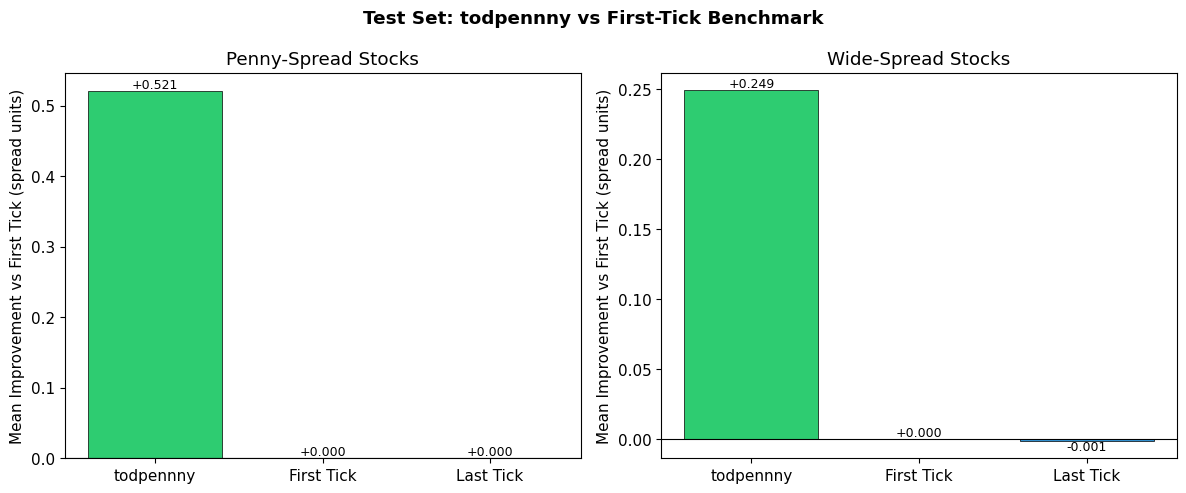

In [52]:
heldout_test_all = todpennny_heldout_results['test_all'].copy()
heldout_test_all['strategy_vs_first_tick'] = heldout_test_all['strategy'] - heldout_test_all['first_tick']
heldout_test_all['last_tick_vs_first_tick'] = heldout_test_all['last_tick'] - heldout_test_all['first_tick']

print("=" * 70)
print("Mean Improvement over First Tick ($)")
print("=" * 70)
for arch in ['penny', 'wide', 'all']:
    sub = heldout_test_all if arch == 'all' else heldout_test_all[heldout_test_all['archetype'] == arch]
    wr = (sub['strategy_vs_first_tick'] > 0).mean()
    print(f"  {arch.title():6s} (n={len(sub):4d}, win_rate={wr:.1%})  todpennny: ${sub['strategy_vs_first_tick'].mean():+.6f}  First Tick: $0.000000  Last Tick: ${sub['last_tick_vs_first_tick'].mean():+.6f}")

print()
print("=" * 70)
print("Mean Improvement over First Tick (spread units)")
print("=" * 70)
for arch in ['penny', 'wide']:
    sub = heldout_test_all[heldout_test_all['archetype'] == arch]
    med_spr = sub['med_spread'].median()
    print(f'\n  {arch.title()} (median spread = ${med_spr:.4f}):')
    print(f"    {'todpennny':20s}: {sub['strategy_vs_first_tick'].mean() / med_spr:+.4f} spread units")
    print(f"    {'First Tick':20s}: {0.0:+.4f} spread units")
    print(f"    {'Last Tick':20s}: {sub['last_tick_vs_first_tick'].mean() / med_spr:+.4f} spread units")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['todpennny', 'First Tick', 'Last Tick']
colors = ['#2ecc71', '#e67e22', '#3498db']
for ax, arch in zip(axes, ['penny', 'wide']):
    sub = heldout_test_all[heldout_test_all['archetype'] == arch]
    med_spr = sub['med_spread'].median()
    means = [sub['strategy_vs_first_tick'].mean() / med_spr, 0.0, sub['last_tick_vs_first_tick'].mean() / med_spr]
    bars = ax.bar(labels, means, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('Mean Improvement vs First Tick (spread units)')
    ax.set_title(f'{arch.title()}-Spread Stocks')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
fig.suptitle('Test Set: todpennny vs First-Tick Benchmark', fontweight='bold')
plt.tight_layout()
plt.show()


## Stock-Level Held-Out Results

These cells break the final held-out test down by stock relative to the first-tick benchmark. They show where `todpennny` beats the start-of-minute execution baseline and where it struggles.


In [53]:
import numpy as np
import pandas as pd

heldout_test_all = todpennny_heldout_results['test_all'].copy()
heldout_test_all['strategy_vs_first_tick'] = heldout_test_all['strategy'] - heldout_test_all['first_tick']
heldout_test_all['last_tick_vs_first_tick'] = heldout_test_all['last_tick'] - heldout_test_all['first_tick']

stock_summary = (
    heldout_test_all
    .groupby(['ticker', 'archetype'], as_index=False)
    .agg(
        mean_improvement_dollars=('strategy_vs_first_tick', 'mean'),
        first_tick_dollars=('first_tick', lambda s: 0.0),
        last_tick_dollars=('last_tick_vs_first_tick', 'mean'),
        med_spread=('med_spread', 'median'),
        std_dollars=('strategy_vs_first_tick', 'std'),
        win_rate=('strategy_vs_first_tick', lambda s: (s > 0).mean()),
        n_minutes=('strategy_vs_first_tick', 'size'),
    )
)

stock_summary['mean_improvement_spreads'] = stock_summary['mean_improvement_dollars'] / stock_summary['med_spread']
stock_summary['first_tick_spreads'] = 0.0
stock_summary['last_tick_spreads'] = stock_summary['last_tick_dollars'] / stock_summary['med_spread']
stock_summary['std_spreads'] = stock_summary['std_dollars'] / stock_summary['med_spread']
stock_summary = stock_summary.sort_values(['archetype', 'ticker']).reset_index(drop=True)

stock_summary[[
    'ticker', 'archetype', 'mean_improvement_dollars', 'mean_improvement_spreads',
    'first_tick_spreads', 'last_tick_spreads', 'std_spreads', 'win_rate', 'n_minutes'
]].style.format({
    'mean_improvement_dollars': '{:.6f}',
    'mean_improvement_spreads': '{:.4f}',
    'first_tick_spreads': '{:.4f}',
    'last_tick_spreads': '{:.4f}',
    'std_spreads': '{:.4f}',
    'win_rate': '{:.1%}',
})


,ticker,archetype,mean_improvement_dollars,mean_improvement_spreads,first_tick_spreads,last_tick_spreads,std_spreads,win_rate,n_minutes
0,INTC,penny,0.004833,0.4833,0.0000,0.0000,0.8332,35.0%,240
1,MSFT,penny,0.005583,0.5583,0.0000,0.0000,0.8802,40.4%,240
2,AAPL,wide,0.023333,0.1944,0.0000,-0.0174,0.5445,43.3%,240
3,AMZN,wide,0.019875,0.1728,0.0000,-0.0072,0.4687,40.8%,240
4,GOOG,wide,0.061500,0.2460,0.0000,0.0098,0.7735,60.4%,240


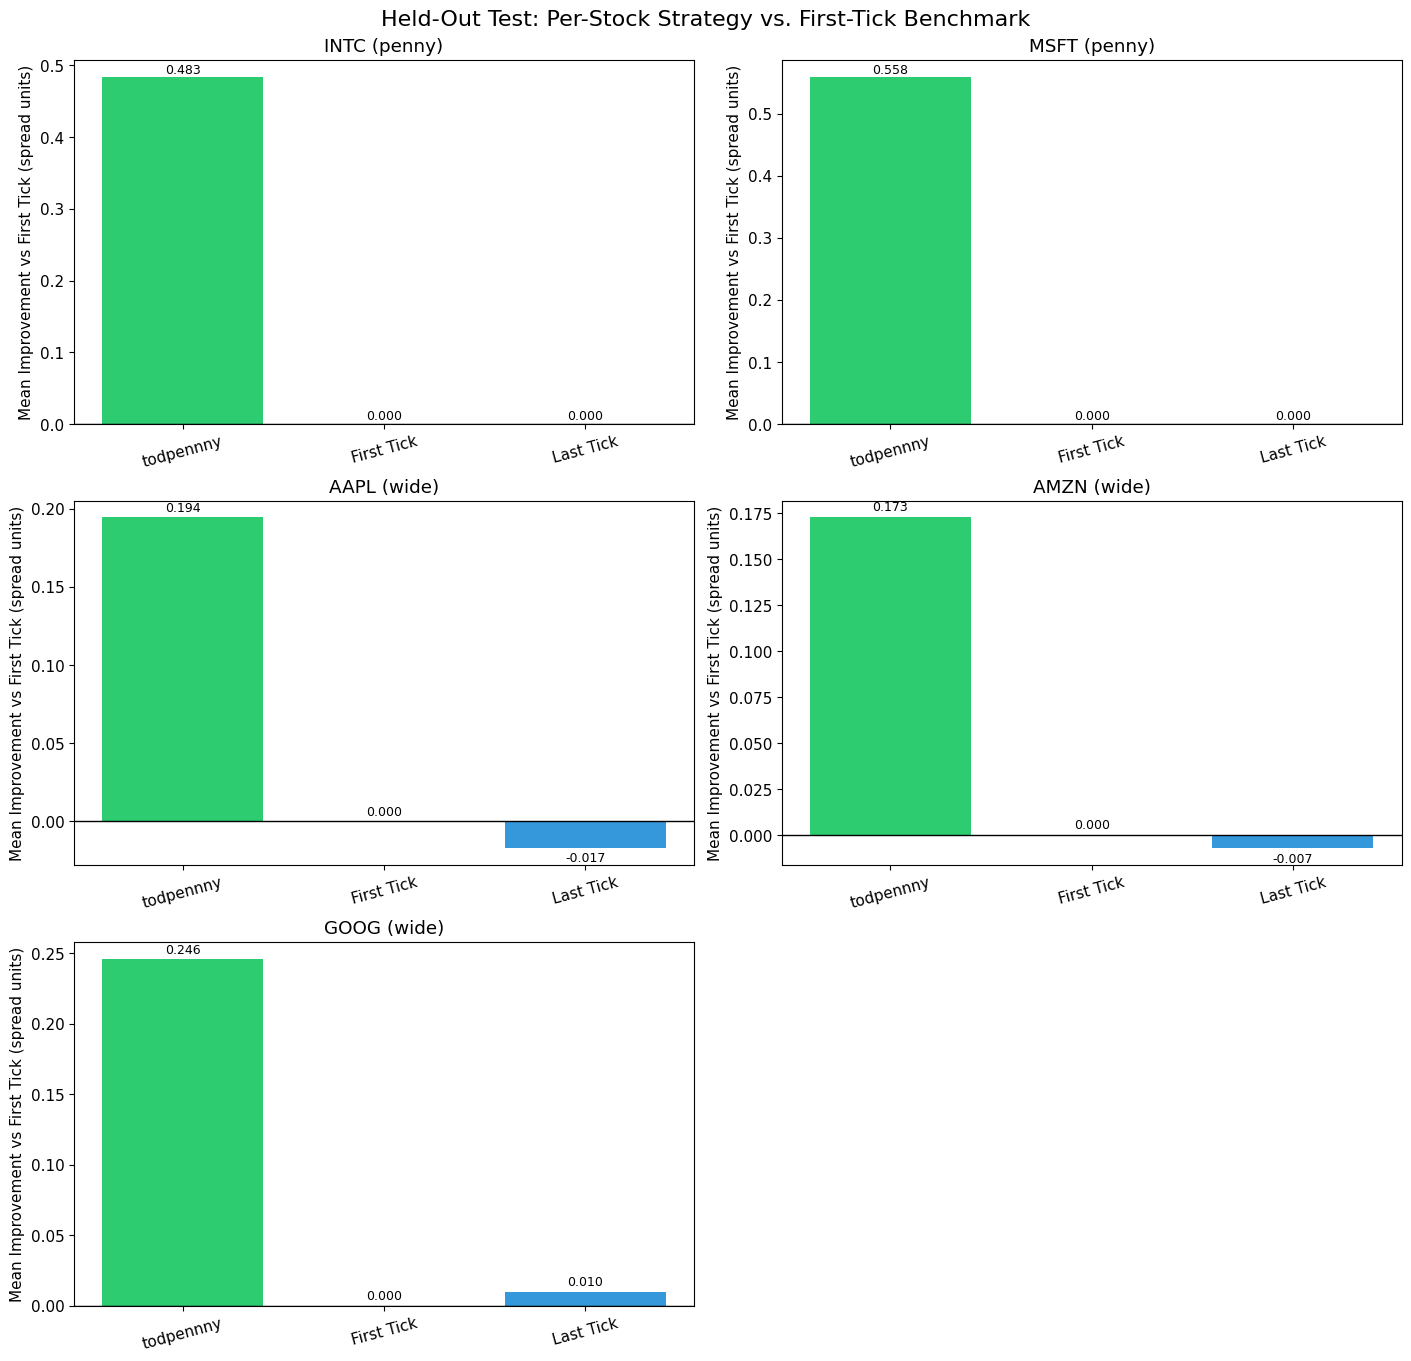

In [54]:
tickers = stock_summary['ticker'].tolist()
n = len(tickers)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, stock_summary.iterrows()):
    labels = ['todpennny', 'First Tick', 'Last Tick']
    values = [
        row['mean_improvement_spreads'],
        0.0,
        row['last_tick_spreads'],
    ]
    colors = ['#2ecc71', '#e67e22', '#3498db']
    bars = ax.bar(labels, values, color=colors)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f"{row['ticker']} ({row['archetype']})")
    ax.set_ylabel('Mean Improvement vs First Tick (spread units)')
    ax.tick_params(axis='x', rotation=15)

    for bar, value in zip(bars, values):
        offset = 0.002 if value >= 0 else -0.002
        va = 'bottom' if value >= 0 else 'top'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f'{value:.3f}',
            ha='center',
            va=va,
            fontsize=9,
        )

for ax in axes[n:]:
    ax.axis('off')

fig.suptitle('Held-Out Test: Per-Stock Strategy vs. First-Tick Benchmark', fontsize=16)
plt.show()


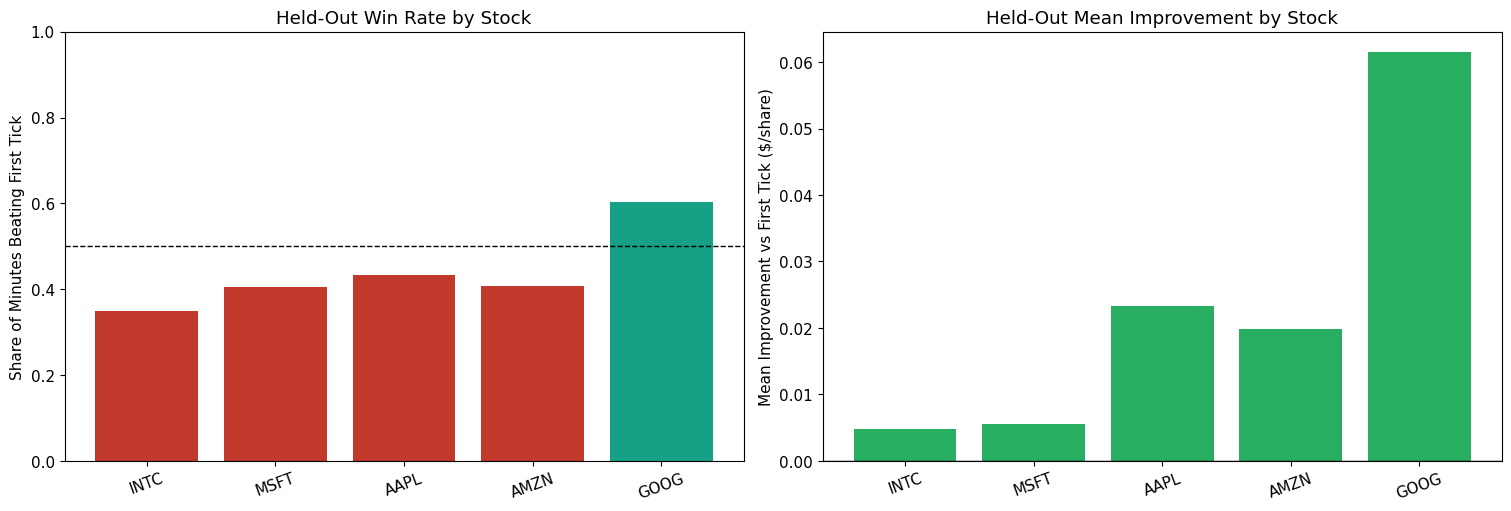

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

win_colors = ['#16a085' if x >= 0.5 else '#c0392b' for x in stock_summary['win_rate']]
axes[0].bar(stock_summary['ticker'], stock_summary['win_rate'], color=win_colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Held-Out Win Rate by Stock')
axes[0].set_ylabel('Share of Minutes Beating First Tick')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

pnl_colors = ['#27ae60' if x >= 0 else '#c0392b' for x in stock_summary['mean_improvement_dollars']]
axes[1].bar(stock_summary['ticker'], stock_summary['mean_improvement_dollars'], color=pnl_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Held-Out Mean Improvement by Stock')
axes[1].set_ylabel('Mean Improvement vs First Tick ($/share)')
axes[1].tick_params(axis='x', rotation=20)

plt.show()


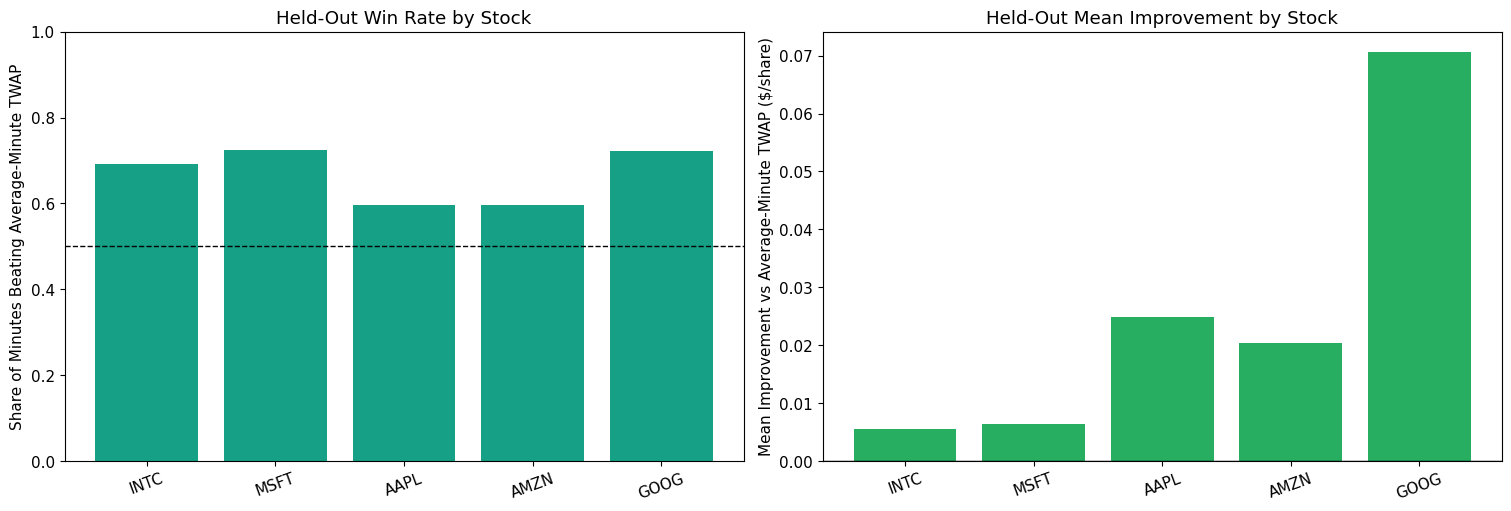

In [56]:
avg_twap_summary = (
    todpennny_heldout_results['test_all']
    .groupby(['ticker', 'archetype'], as_index=False)
    .agg(
        mean_improvement_dollars=('strategy', 'mean'),
        mean_improvement_spreads=('strategy', lambda s: s.mean()),
        win_rate=('strategy', lambda s: (s > 0).mean()),
        med_spread=('med_spread', 'median'),
    )
)
avg_twap_summary['mean_improvement_spreads'] = avg_twap_summary['mean_improvement_dollars'] / avg_twap_summary['med_spread']
avg_twap_summary = avg_twap_summary.sort_values(['archetype', 'ticker']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

win_colors = ['#16a085' if x >= 0.5 else '#c0392b' for x in avg_twap_summary['win_rate']]
axes[0].bar(avg_twap_summary['ticker'], avg_twap_summary['win_rate'], color=win_colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Held-Out Win Rate by Stock')
axes[0].set_ylabel('Share of Minutes Beating Average-Minute TWAP')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

pnl_colors = ['#27ae60' if x >= 0 else '#c0392b' for x in avg_twap_summary['mean_improvement_dollars']]
axes[1].bar(avg_twap_summary['ticker'], avg_twap_summary['mean_improvement_dollars'], color=pnl_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Held-Out Mean Improvement by Stock')
axes[1].set_ylabel('Mean Improvement vs Average-Minute TWAP ($/share)')
axes[1].tick_params(axis='x', rotation=20)

plt.show()


## Buy vs Sell Breakdown

These cells split the first-tick benchmark results by execution side so you can see whether the held-out edge comes from buys, sells, or both.


In [57]:
def summarize_side_against_first_tick(side_name, side_df):
    side_df = side_df.copy()
    side_df['strategy_vs_first_tick'] = side_df['strategy'] - side_df['first_tick']
    side_df['last_tick_vs_first_tick'] = side_df['last_tick'] - side_df['first_tick']
    summary = (
        side_df
        .groupby(['ticker', 'archetype'], as_index=False)
        .agg(
            mean_improvement_dollars=('strategy_vs_first_tick', 'mean'),
            mean_last_tick_dollars=('last_tick_vs_first_tick', 'mean'),
            med_spread=('med_spread', 'median'),
            win_rate=('strategy_vs_first_tick', lambda s: (s > 0).mean()),
            n_minutes=('strategy_vs_first_tick', 'size'),
        )
    )
    summary['mean_improvement_spreads'] = summary['mean_improvement_dollars'] / summary['med_spread']
    summary['last_tick_spreads'] = summary['mean_last_tick_dollars'] / summary['med_spread']
    summary.insert(0, 'side', side_name)
    return summary.sort_values(['archetype', 'ticker']).reset_index(drop=True)

buy_stock_summary = summarize_side_against_first_tick('buy', test_buy)
sell_stock_summary = summarize_side_against_first_tick('sell', test_sell)
side_stock_summary = pd.concat([buy_stock_summary, sell_stock_summary], ignore_index=True)
side_stock_summary[['side', 'ticker', 'archetype', 'mean_improvement_dollars', 'mean_improvement_spreads', 'last_tick_spreads', 'win_rate', 'n_minutes']].style.format({
    'mean_improvement_dollars': '{:.6f}',
    'mean_improvement_spreads': '{:.4f}',
    'last_tick_spreads': '{:.4f}',
    'win_rate': '{:.1%}',
})


,side,ticker,archetype,mean_improvement_dollars,mean_improvement_spreads,last_tick_spreads,win_rate,n_minutes
0,buy,INTC,penny,0.003833,0.3833,0.0917,30.0%,120
1,buy,MSFT,penny,0.006417,0.6417,0.2500,46.7%,120
2,buy,AAPL,wide,0.017750,0.1479,0.3500,35.8%,120
3,buy,AMZN,wide,0.018417,0.1601,0.0877,36.7%,120
4,buy,GOOG,wide,0.077500,0.3100,0.1200,67.5%,120
5,sell,INTC,penny,0.005833,0.5833,-0.0917,40.0%,120
6,sell,MSFT,penny,0.004750,0.4750,-0.2500,34.2%,120
7,sell,AAPL,wide,0.028917,0.2410,-0.3847,50.8%,120
8,sell,AMZN,wide,0.021333,0.1855,-0.1022,45.0%,120
9,sell,GOOG,wide,0.045500,0.1820,-0.1003,53.3%,120


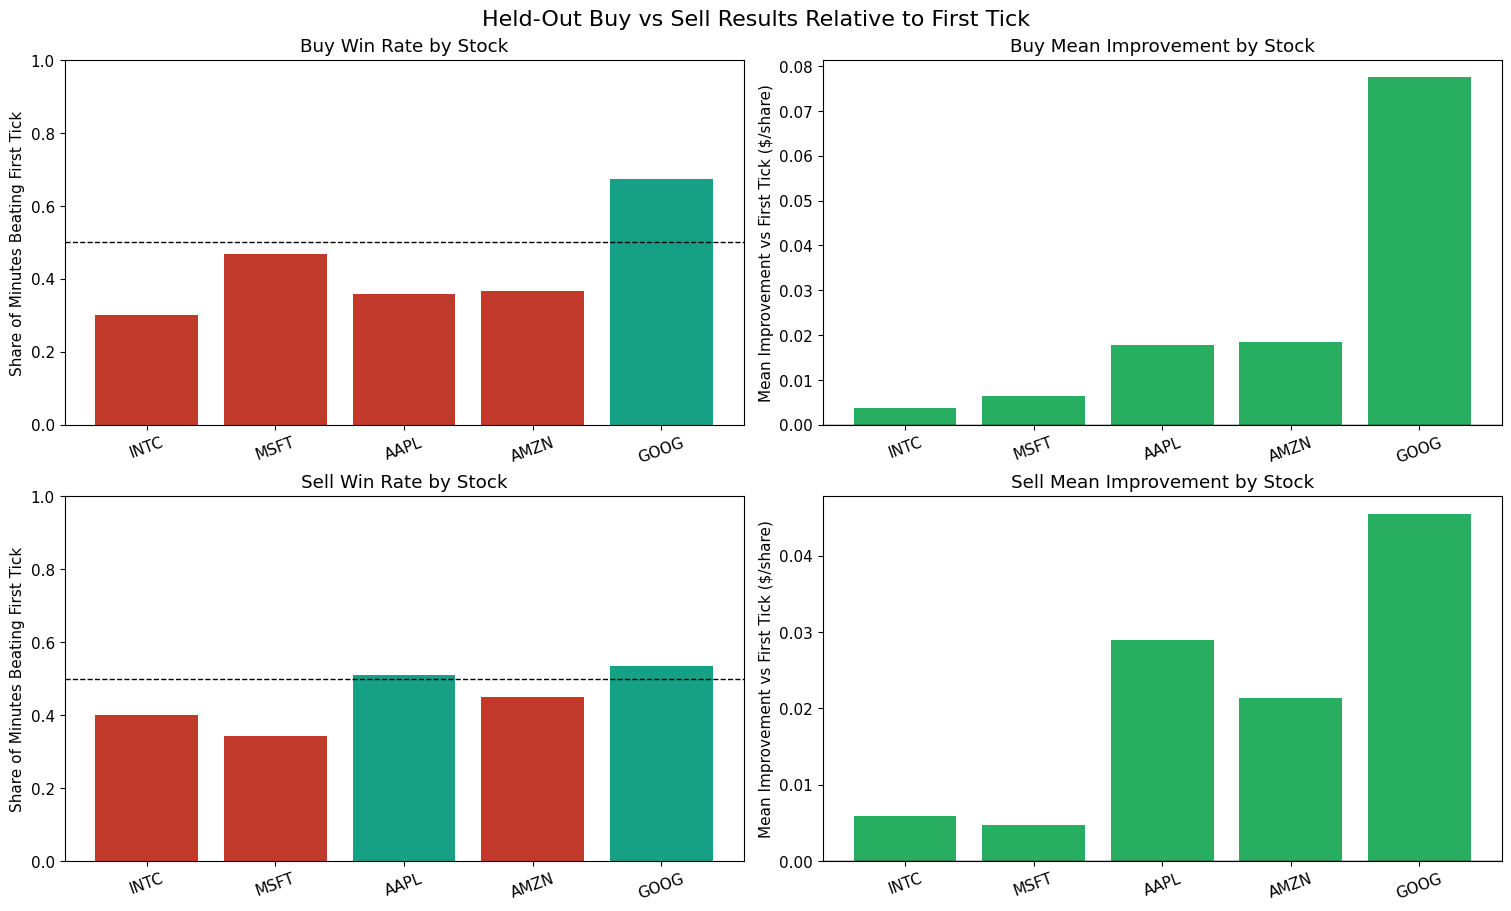

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
side_frames = [('Buy', buy_stock_summary), ('Sell', sell_stock_summary)]

for row_idx, (side_label, summary) in enumerate(side_frames):
    win_colors = ['#16a085' if x >= 0.5 else '#c0392b' for x in summary['win_rate']]
    axes[row_idx, 0].bar(summary['ticker'], summary['win_rate'], color=win_colors)
    axes[row_idx, 0].axhline(0.5, color='black', linestyle='--', linewidth=1)
    axes[row_idx, 0].set_title(f'{side_label} Win Rate by Stock')
    axes[row_idx, 0].set_ylabel('Share of Minutes Beating First Tick')
    axes[row_idx, 0].set_ylim(0, 1)
    axes[row_idx, 0].tick_params(axis='x', rotation=20)

    pnl_colors = ['#27ae60' if x >= 0 else '#c0392b' for x in summary['mean_improvement_dollars']]
    axes[row_idx, 1].bar(summary['ticker'], summary['mean_improvement_dollars'], color=pnl_colors)
    axes[row_idx, 1].axhline(0, color='black', linewidth=1)
    axes[row_idx, 1].set_title(f'{side_label} Mean Improvement by Stock')
    axes[row_idx, 1].set_ylabel('Mean Improvement vs First Tick ($/share)')
    axes[row_idx, 1].tick_params(axis='x', rotation=20)

fig.suptitle('Held-Out Buy vs Sell Results Relative to First Tick', fontsize=16)
plt.show()
